# Episode 2 — Variable types & the scale trap

**Goal:** answer *why* textbooks say "standardize your data" — and show the two cases where standardization is the *wrong* move.

Follows on directly from Episode 1: rotation preserves accuracy (Ep. 1 Part 2), non-uniform scaling doesn't. This episode shows *why*, and what to do about it.

https://developers.google.com/machine-learning/crash-course/prereqs-and-prework

https://scikit-learn.org/stable/modules/ensemble.html

## Setup — use the `.venv` at the tutorial root

Same setup as Episode 1. If you already have the venv active and packages installed, skip to the sanity check.

```bash
# from dimensionality_reduction/
source .venv/bin/activate            # or create with: python3 -m venv .venv
pip install -r requirements.txt
```

In VS Code, click the kernel picker (top-right) and pick `.venv (Python 3.x)`.

In [1]:
import sys
import importlib.metadata as md

print(f'python executable: {sys.executable}')
print()
for pkg in ('numpy', 'pandas', 'scikit-learn', 'matplotlib'):
    try:
        print(f'  {pkg:14s} {md.version(pkg)}')
    except md.PackageNotFoundError:
        print(f'  {pkg:14s} NOT INSTALLED  <- run: pip install -r requirements.txt')

print()
print('OK: .venv is active' if '.venv' in sys.executable else 'WARNING: not in .venv')

python executable: /Library/Developer/CommandLineTools/usr/bin/python3

  numpy          2.0.2
  pandas         2.3.3
  scikit-learn   1.6.1
  matplotlib     3.9.4



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

RNG = 0
np.set_printoptions(precision=4, suppress=True)

## What is "scale," anyway?

Before the taxonomy, one word we throw around a lot. **Scale = the typical numerical range a feature occupies.** Three ways to think about it:

- **Units.** Age is in years (0–100). Income is in dollars (10⁴–10⁶). Same information, radically different numbers.
- **Spread.** Standard deviation of the column. Age σ ≈ 15. Income σ ≈ 25 000. The optimizer sees the spreads, not the meanings.
- **Range.** `max - min`. A feature ranging over `[0, 1]` and one ranging over `[0, 100 000]` are on wildly different scales even if both are meaningful.

The problem isn't that any individual scale is *wrong* — years, dollars, and clicks are all correct measurements of real things. The problem is that when features on different scales are fed to a **weight-based model** (linear regression, logistic regression, neural nets) or a **distance-based model** (k-NN, k-means, SVM), the model can't tell "big number because it's important" apart from "big number because the unit is small." The scale mismatch **leaks into the math** — coefficients, gradients, distances all get distorted.

### When do you reach for a scaling transform?

Four decision axes, in order of importance:

1. **What model are you training?**
   - Linear / logistic / SVM / neural net input → **you need to scale**.
   - k-NN / k-means / any distance-based method → **you need to scale**.
   - PCA / SVD → **you need to scale** (PCA's first component will otherwise just point at whatever feature has the biggest variance).
   - Trees / random forest / gradient boosting → **don't bother**. Splits are scale-invariant.

2. **What does the feature's distribution look like?**
   - Roughly bell-shaped, no wild outliers → `StandardScaler` (z-score).
   - Bell-shaped but with occasional outliers you want to keep → `RobustScaler` (uses median + IQR instead of mean + std).
   - Bounded and you *need* bounded output (feeding into a sigmoid, an image pipeline expecting `[0, 1]`) → `MinMaxScaler`.
   - Heavy-tailed / skewed (counts, prices, follower counts) → `log1p` first, *then* standardize.

3. **What is the semantic role of the feature?**
   - It's a magnitude and direction of a vector, and only direction matters (embeddings, TF-IDF rows, attention keys) → **unit-vector normalize** (`x / ||x||`). Not a column-wise transform.
   - It's already one-hot or otherwise sparse → **leave it alone**. Standardization destroys sparsity (Part 5 Case 2).
   - It's a boolean → **leave it alone**. It's already on `{0, 1}`.

4. **Where in the pipeline are you?**
   - Before splitting train/test → **wrong**. This leaks test statistics into the scaler.
   - Inside a CV loop / after the split, fit on train, transform train and test → **right**. Ep. 3 will pin this down.

### The one-line decision tree

> *Is my model weight-based or distance-based? → Yes → Is my feature continuous and non-sparse? → Yes → Is its distribution heavy-tailed? → Yes: `log1p` then `StandardScaler`. No: `StandardScaler`.*

Everything else in Part 5 is exceptions to this tree.

## Part 1 — Variable types (quick tour)

"Standardize your data" means different things for different types. A one-line taxonomy of what you might find in a dataframe:

| Type | Example | Standardize? |
|---|---|---|
| Numerical continuous | height, temperature, price | **Yes** (usually) |
| Numerical discrete counts | clicks, purchases | **No** — log first |
| Categorical nominal | country, product SKU | No — one-hot / embed |
| Categorical ordinal | rating stars, S/M/L | Sometimes (as integer) |
| Boolean | is_premium | No |
| Datetime | signup_date | No — decompose first |
| Text | review body | No — vectorize |

The trap: `StandardScaler().fit_transform(df)` on the whole dataframe silently damages three of the seven types. Let's detect them programmatically.

In [3]:
# Mixed-type dataframe: what a real feature store looks like.
df = pd.DataFrame({
    'age':          [25, 42, 31, 58, 19],                           # numerical continuous
    'income':       [45000.0, 82000.0, 71000.0, 120000.0, 32000.0], # numerical continuous
    'clicks':       [0, 3, 1, 250, 0],                              # count (skewed)
    'country':      ['US', 'IN', 'US', 'DE', 'IN'],                 # categorical nominal
    'tier':         ['bronze', 'gold', 'silver', 'gold', 'bronze'], # categorical ordinal
    'is_premium':   [False, True, False, True, False],              # boolean
    'signup_date':  pd.to_datetime(['2023-01-15', '2022-11-01',
                                    '2024-03-20', '2021-06-30',
                                    '2023-08-10']),
})

def classify_columns(df):
    out = []
    for col in df.columns:
        s = df[col]
        if pd.api.types.is_bool_dtype(s):
            kind = 'boolean'
            scale = 'no'
        elif pd.api.types.is_datetime64_any_dtype(s):
            kind = 'datetime'
            scale = 'no - decompose first'
        elif pd.api.types.is_numeric_dtype(s):
            # crude heuristic: integer-only + skewed -> count
            is_int = pd.api.types.is_integer_dtype(s) or (s.dropna() % 1 == 0).all()
            skew = s.skew()
            if is_int and abs(skew) > 1.5:
                kind = 'numerical count (skewed)'
                scale = 'no - log1p first'
            else:
                kind = 'numerical continuous'
                scale = 'yes'
        else:
            n_unique = s.nunique()
            kind = f'categorical ({n_unique} levels)'
            scale = 'no - one-hot / embed'
        out.append({'column': col, 'kind': kind, 'standardize?': scale})
    return pd.DataFrame(out)

classify_columns(df)

,column,kind,standardize?
0,age,numerical continuous,yes
1,income,numerical continuous,yes
2,clicks,numerical count (skewed),no - log1p first
3,country,categorical (3 levels),no - one-hot / embed
4,tier,categorical (3 levels),no - one-hot / embed
5,is_premium,boolean,no
6,signup_date,datetime,no - decompose first


### Aside — standardization vs normalization (the words matter)

The table above says "standardize?" — let's pin down what that word means, because it's routinely confused with "normalize."

**Standardization** (a.k.a. *z-score scaling*, `sklearn.preprocessing.StandardScaler`):

$$x' = \frac{x - \mu}{\sigma}$$

Subtract the mean, divide by the standard deviation. Output has **mean 0, std 1**. Range is unbounded — a value 3 standard deviations above the mean becomes `3.0`. Assumes the feature is roughly Gaussian; doesn't require it.

**Normalization** — overloaded term. Three common meanings:

1. **Min-max scaling** (`MinMaxScaler`): $x' = \frac{x - \min}{\max - \min}$. Output squeezed to **[0, 1]**. Preserves the shape of the distribution but is destroyed by a single outlier (one bad value moves `max` and squashes everything else).
2. **Unit-vector normalization** (`Normalizer`, or `x / ||x||`): scales each *row* (not column) to length 1. This is what happens inside cosine similarity, attention, and every embedding-based retrieval system — direction matters, magnitude doesn't.
3. **Statistical "normalization"** — any transform that makes a distribution more Gaussian-shaped: `log1p`, Box-Cox, Yeo-Johnson, quantile transform. Different problem, same word.

**Why we need any of it.** The next four parts show it, but the one-line answer: **linear models and gradient-based optimizers implicitly assume all features live on the same scale.** When they don't, the loss surface deforms into an anisotropic valley (Part 3), and the optimizer either zigzags (SGD) or wastes memory papering over it (Adam, Part 4). Standardization is the fix. It doesn't change the *information* in your features — it changes the *geometry* the optimizer sees.

**Which one to use.** Standardization for linear models, SVMs, PCA, and neural net inputs. Min-max when you need bounded outputs (e.g., feeding into a sigmoid, or image pixel scaling to `[0,1]`). Unit-vector normalization when direction is the signal and magnitude is noise (embeddings, TF-IDF, cosine retrieval — Ep. 22). Statistical normalization (log1p etc.) when your feature is skewed *before* you standardize (Part 5 Case 3).

**Callback to Ep. 1.** Standardization and min-max are both non-uniform axis-wise scalings — they *stretch each axis independently*. That's why they change the geometry. Rotation (Ep. 1) is uniform and preserves distances; scaling doesn't.

## Part 2 — The scale trap on a real classifier

Two Gaussian blobs, same setup as Episode 1. Then multiply the second feature by 100 — pretend it's income (dollars) while the first is age (years). Watch what happens to a linear model.

### Aside — optimization, gradients, and "converged"

A one-paragraph refresher, because the whole rest of the episode leans on this:

- **Loss function.** A single number that says how wrong the current weights are on the training data. For logistic regression it's the negative log-likelihood: high when predictions disagree with labels, zero when they're perfect. Training = find weights that make it small.
- **Gradient.** The vector of partial derivatives of the loss with respect to each weight. It points in the direction the loss increases *fastest* at your current point. So `-gradient` points **downhill** — toward a better set of weights.
- **Gradient descent.** Take a small step in the `-gradient` direction, recompute, repeat: `w ← w - lr * gradient`. `lr` (learning rate) is the step size. Too big overshoots; too small crawls.
- **Converged.** Successive steps stop changing the weights (or the loss) by more than a tolerance `tol` (default `1e-4` in sklearn). The solver reports how many iterations that took in `clf.n_iter_`.
- **`max_iter`.** A safety cap. If the solver hits it without converging, sklearn prints a `ConvergenceWarning` and hands you whatever weights it stopped at — not the optimum.

Fewer iterations to converge = the loss surface is easier to walk downhill. That's the number to watch below. Part 3 draws the picture that makes this obvious.

In [4]:
X, y = make_blobs(
    n_samples=400,
    centers=[[-2.0, -2.0], [2.0, 2.0]],
    cluster_std=1.0,
    random_state=RNG,
)

# Blow up the second feature's scale (units-of-dollars trick).
X_wild = X * np.array([1.0, 100.0])

# Fit without scaling — high max_iter to give it a fair chance.
clf_wild = LogisticRegression(max_iter=5000).fit(X_wild, y)
print('=== Unscaled features ===')
print(f'coefficients:  {clf_wild.coef_[0]}')
print(f'accuracy:      {clf_wild.score(X_wild, y):.4f}')
print(f'iters to converge: {clf_wild.n_iter_[0]}')
print()
print('The second coefficient looks ~50x more important than the first.')
print('That is an artifact of units. Not truth.')

=== Unscaled features ===
coefficients:  [2.1844 0.0325]
accuracy:      1.0000
iters to converge: 22

The second coefficient looks ~50x more important than the first.
That is an artifact of units. Not truth.


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_wild)

clf_scaled = LogisticRegression(max_iter=5000).fit(X_scaled, y)
print('=== After StandardScaler ===')
print(f'coefficients:  {clf_scaled.coef_[0]}')
print(f'accuracy:      {clf_scaled.score(X_scaled, y):.4f}')
print(f'iters to converge: {clf_scaled.n_iter_[0]}')
print()
print('Coefficients are balanced. Convergence is faster.')
print('Same information, different loss surface -> different optimization behavior.')

=== After StandardScaler ===
coefficients:  [3.18   3.0718]
accuracy:      1.0000
iters to converge: 9

Coefficients are balanced. Convergence is faster.
Same information, different loss surface -> different optimization behavior.


## Part 3 — The loss-surface picture

For a quadratic loss $L(w_1, w_2) = \tfrac{1}{2}(a\, w_1^2 + b\, w_2^2)$:

- $a = b$ (isotropic): round bowl. Gradient points at the minimum. Descent is straight.
- $a \gg b$ or $b \gg a$ (anisotropic): long elongated valley. Gradient mostly points *across* the valley, not *down* it. Descent zigzags.

Standardization doesn't "balance features." It **makes the loss surface round**, so gradient descent walks straight.

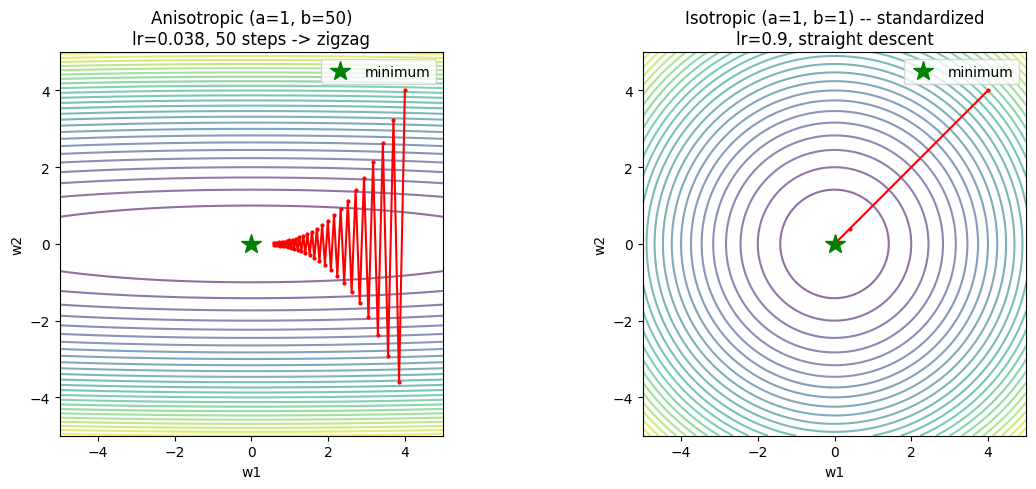

Anisotropic: distance from minimum after 50 steps = 0.5769
Isotropic:   distance from minimum after 50 steps = 5.6569e-50


In [6]:
def loss(W1, W2, a, b):
    return 0.5 * (a * W1**2 + b * W2**2)

def grad(w, a, b):
    return np.array([a * w[0], b * w[1]])

def gd_trajectory(a, b, w0, lr, steps):
    w = np.array(w0, dtype=float)
    traj = [w.copy()]
    for _ in range(steps):
        w = w - lr * grad(w, a, b)
        traj.append(w.copy())
    return np.array(traj)

w1_range = np.linspace(-5, 5, 300)
w2_range = np.linspace(-5, 5, 300)
W1, W2 = np.meshgrid(w1_range, w2_range)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LEFT: anisotropic (unscaled features), lr limited by worst direction.
a, b = 1.0, 50.0
lr_anis = 0.038  # just below 2 / max(a, b) = 0.04
traj_anis = gd_trajectory(a, b, w0=[4.0, 4.0], lr=lr_anis, steps=50)
axes[0].contour(W1, W2, loss(W1, W2, a, b), levels=25, cmap='viridis', alpha=0.6)
axes[0].plot(traj_anis[:, 0], traj_anis[:, 1], 'r.-', markersize=4)
axes[0].plot(0, 0, 'g*', markersize=15, label='minimum')
axes[0].set_title(f'Anisotropic (a=1, b=50)\nlr={lr_anis}, 50 steps -> zigzag')
axes[0].set_xlabel('w1'); axes[0].set_ylabel('w2')
axes[0].legend(); axes[0].set_aspect('equal')

# RIGHT: isotropic (standardized features), lr can be aggressive.
a, b = 1.0, 1.0
lr_iso = 0.9
traj_iso = gd_trajectory(a, b, w0=[4.0, 4.0], lr=lr_iso, steps=50)
axes[1].contour(W1, W2, loss(W1, W2, a, b), levels=25, cmap='viridis', alpha=0.6)
axes[1].plot(traj_iso[:, 0], traj_iso[:, 1], 'r.-', markersize=4)
axes[1].plot(0, 0, 'g*', markersize=15, label='minimum')
axes[1].set_title(f'Isotropic (a=1, b=1) -- standardized\nlr={lr_iso}, straight descent')
axes[1].set_xlabel('w1'); axes[1].set_ylabel('w2')
axes[1].legend(); axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

# Report distance to minimum after 50 steps.
print(f'Anisotropic: distance from minimum after 50 steps = {np.linalg.norm(traj_anis[-1]):.4f}')
print(f'Isotropic:   distance from minimum after 50 steps = {np.linalg.norm(traj_iso[-1]):.4e}')

## Interlude — the gradient descent family tree

Before Part 4 introduces Adam, here's the lineage. Every optimizer below is trying to fix a problem with the one above it.

| Optimizer | Update rule (per step) | What problem it solves |
|---|---|---|
| **GD** (batch) | $w \leftarrow w - \eta \, \nabla L(w)$ over the *whole* dataset | The baseline. Cost per step scales with dataset size — untenable at scale. |
| **SGD** | Same, but $\nabla L$ estimated from **one sample** (or a small **mini-batch**) | Cheap per step; noisy gradient acts as free regularization. But noisy → zigzags near the minimum. |
| **SGD + momentum** | $v \leftarrow \beta v + \nabla L$; $w \leftarrow w - \eta v$ | Accumulates a "velocity" of past gradients. Damps zigzag, accelerates along consistent directions. Rolling ball, not sliding block. |
| **AdaGrad** | $w_i \leftarrow w_i - \frac{\eta}{\sqrt{\sum g_i^2}} g_i$ (per-parameter) | Rare features get big learning rates, common features get small ones. But the sum grows forever → learning rate eventually collapses to zero. |
| **RMSProp** | Same as AdaGrad but with an **exponential moving average** of $g_i^2$ instead of a sum | Fixes AdaGrad's dying learning rate. Adapts to *recent* gradient magnitudes. |
| **Adam** | RMSProp + momentum, with bias correction (the update rule we implement below) | The default for deep learning. Momentum handles direction, RMSProp part handles per-parameter scale. |
| **AdamW** | Adam, but **weight decay decoupled** from the gradient | Fixes a bug: L2 regularization in vanilla Adam gets divided by $\sqrt{v_i}$, so it's not really L2 anymore. AdamW is Adam done right. Standard for transformers. |
| **Adafactor** | Adam-like, but stores factored (row + column) moments instead of full $v$ | Cuts optimizer memory 2×. Used for training massive LLMs where every gigabyte of GPU memory counts. |

**One-line mental model:** momentum smooths the *direction* of the update; RMSProp/Adam smooths the *magnitude*, per parameter, based on that parameter's own gradient history.

**A common source of confusion.** Don't confuse this family with **boosting** — AdaBoost / Gradient Boosting / XGBoost. Same word ("gradient"), completely different idea: boosting fits a *sequence of weak models* to the residuals of the previous ones. It's an ensemble method, not an optimizer. We use it in later episodes but it's not what's happening inside `LogisticRegression.fit()`.

**Why this matters for scaling.** SGD without adaptive per-parameter learning rates gets destroyed by anisotropic loss surfaces (Part 3). Adam papers over the damage. Part 4 shows the receipts.

## Part 4 — Adam masks the scaling problem

The pushback: *"I use Adam, so I don't need to scale."*

Adam maintains a running estimate of the **variance of each parameter's gradient** and divides that parameter's update by the square root of that variance. On an anisotropic loss, that means big-gradient directions get *automatically shrunk* and small-gradient directions get *automatically boosted*.

**Adam is doing standardization for you — in gradient space instead of feature space.**

Below: plain SGD and Adam on the same anisotropic loss. SGD zigzags. Adam walks straight.

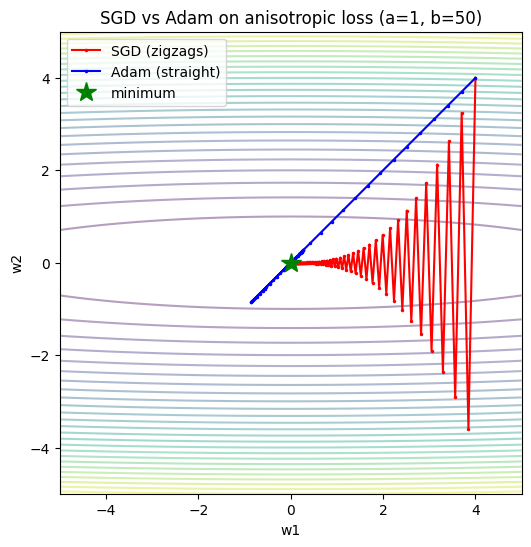

Adam final v_hat (per-parameter gradient variance estimate): [  0.0747 186.7038]
  sqrt(v_hat) ratio: 50.00

Adam is dividing parameter 2 updates by ~50x more than parameter 1.
That is the standardization factor - just applied to gradients, not features.


In [7]:
def adam_step(w, g, m, v, t, lr, b1=0.9, b2=0.999, eps=1e-8):
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g**2
    m_hat = m / (1 - b1**t)
    v_hat = v / (1 - b2**t)
    return w - lr * m_hat / (np.sqrt(v_hat) + eps), m, v

def run(optimizer, a, b, w0, steps, lr):
    w = np.array(w0, dtype=float)
    m = np.zeros_like(w); v = np.zeros_like(w)
    traj = [w.copy()]
    for t in range(1, steps + 1):
        g = grad(w, a, b)
        if optimizer == 'sgd':
            w = w - lr * g
        else:
            w, m, v = adam_step(w, g, m, v, t, lr=lr)
        traj.append(w.copy())
    return np.array(traj), v

a, b = 1.0, 50.0
sgd_traj, _        = run('sgd',  a, b, w0=[4.0, 4.0], steps=200, lr=0.038)
adam_traj, adam_v  = run('adam', a, b, w0=[4.0, 4.0], steps=200, lr=0.3)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(W1, W2, loss(W1, W2, a, b), levels=25, cmap='viridis', alpha=0.4)
ax.plot(sgd_traj[:, 0], sgd_traj[:, 1], 'r.-', markersize=3, label='SGD (zigzags)')
ax.plot(adam_traj[:, 0], adam_traj[:, 1], 'b.-', markersize=3, label='Adam (straight)')
ax.plot(0, 0, 'g*', markersize=15, label='minimum')
ax.set_title('SGD vs Adam on anisotropic loss (a=1, b=50)')
ax.set_xlabel('w1'); ax.set_ylabel('w2')
ax.legend(); ax.set_aspect('equal')
plt.show()

print(f'Adam final v_hat (per-parameter gradient variance estimate): {adam_v}')
print(f'  sqrt(v_hat) ratio: {np.sqrt(adam_v[1] / adam_v[0]):.2f}')
print()
print('Adam is dividing parameter 2 updates by ~{:.0f}x more than parameter 1.'.format(
    np.sqrt(adam_v[1] / adam_v[0])))
print('That is the standardization factor - just applied to gradients, not features.')

### Why "Adam masks, doesn't solve" matters

1. **It hides bugs.** If your training loss looks fine but coefficients / gradient norms are absurd, you'd have caught it before optimization did — if you'd standardized features. Adam quietly rescales the gradient and moves on.
2. **It costs memory.** Adam stores two extra copies of every parameter (`m` and `v`). At LLM scale that is real money. Standardize features and plain SGD or Adafactor becomes viable — halving optimizer state.

Adam is a workaround. Standardization is a fix. Prefer the fix.

## Part 5 — Three cases where standardization is *wrong*

### Case 1: tree models

Random forests, GBTs, XGBoost. Splits are **scale-invariant** — `age > 30` is the same regardless of units.

In [7]:
rf_wild = RandomForestClassifier(random_state=RNG, n_estimators=100).fit(X_wild, y)
rf_scaled = RandomForestClassifier(random_state=RNG, n_estimators=100).fit(
    StandardScaler().fit_transform(X_wild), y
)
print(f'RF accuracy (unscaled):  {rf_wild.score(X_wild, y):.4f}')
print(f'RF accuracy (scaled):    {rf_scaled.score(X_wild, y):.4f}')
print('Identical. Trees do not care about scale. Do not scale for trees.')

RF accuracy (unscaled):  1.0000
RF accuracy (scaled):    1.0000
Identical. Trees do not care about scale. Do not scale for trees.


### Case 2: one-hot columns

From Ep. 1: one-hot columns are 0/1 orthogonal unit vectors. Watch what `StandardScaler` does to them.

In [8]:
df_car = pd.DataFrame({'car': ['toyota', 'honda', 'ferrari',
                                'toyota', 'honda', 'ferrari']})
onehot = pd.get_dummies(df_car['car'], dtype=int).values.astype(float)

print('Before scaling (sparse, exactly 0 or 1):')
print(onehot)
print(f'  fraction of zeros: {(onehot == 0).mean():.2%}')
print()

scaled = StandardScaler().fit_transform(onehot)
print('After StandardScaler (dense, means shifted):')
print(np.round(scaled, 3))
print(f'  fraction of zeros: {(scaled == 0).mean():.2%}')
print()
print('Sparsity destroyed. Interpretation warped.')
print('If you had a sparse solver, it just got dramatically slower.')

Before scaling (sparse, exactly 0 or 1):
[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]
  fraction of zeros: 66.67%

After StandardScaler (dense, means shifted):
[[-0.707 -0.707  1.414]
 [-0.707  1.414 -0.707]
 [ 1.414 -0.707 -0.707]
 [-0.707 -0.707  1.414]
 [-0.707  1.414 -0.707]
 [ 1.414 -0.707 -0.707]]
  fraction of zeros: 0.00%

Sparsity destroyed. Interpretation warped.
If you had a sparse solver, it just got dramatically slower.


### Case 3: count data

Count columns (clicks, purchases, word frequencies) are usually right-skewed: most rows have 0 or 1, a few have hundreds. `StandardScaler` makes those few into 20-sigma outliers that dominate every linear model.

The fix: `np.log1p(x)` first (log of 1+x, handles zeros), then optionally standardize the result.

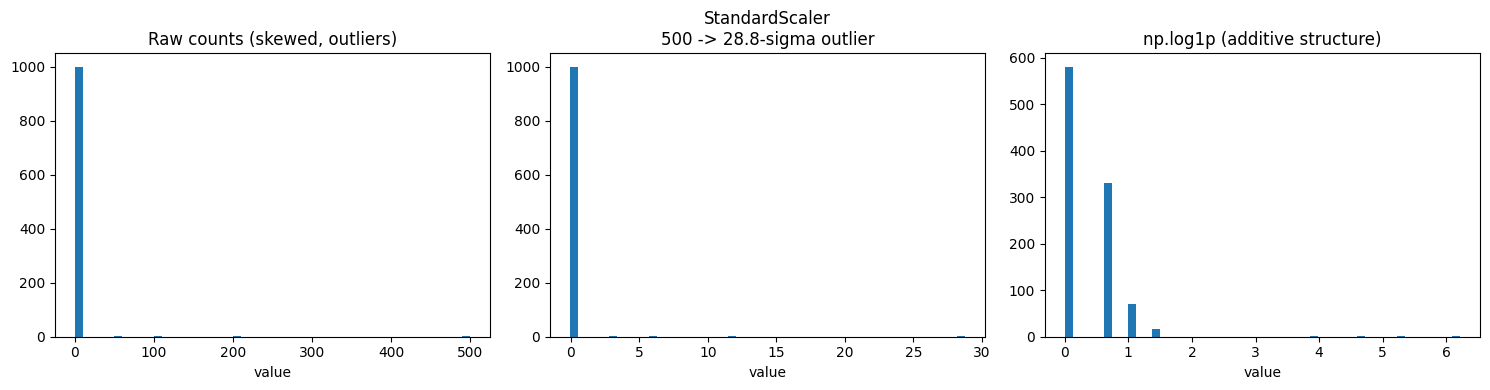

StandardScaler made 500 a 28.8-sigma outlier.
A linear model will spend most of its capacity on those 4 points.
log1p turns multiplicative structure into additive first - do that, then scale.


In [9]:
rng = np.random.default_rng(RNG)
counts = rng.poisson(lam=0.5, size=1000)
counts = np.concatenate([counts, [50, 100, 200, 500]]).astype(float)

standardized = (counts - counts.mean()) / counts.std()
logged = np.log1p(counts)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(counts, bins=50)
axes[0].set_title('Raw counts (skewed, outliers)')
axes[0].set_xlabel('value')

axes[1].hist(standardized, bins=50)
worst_sigma = (500 - counts.mean()) / counts.std()
axes[1].set_title(f'StandardScaler\n500 -> {worst_sigma:.1f}-sigma outlier')
axes[1].set_xlabel('value')

axes[2].hist(logged, bins=50)
axes[2].set_title('np.log1p (additive structure)')
axes[2].set_xlabel('value')

plt.tight_layout()
plt.show()

print(f'StandardScaler made 500 a {worst_sigma:.1f}-sigma outlier.')
print('A linear model will spend most of its capacity on those 4 points.')
print('log1p turns multiplicative structure into additive first - do that, then scale.')

## Recap

- **Standardization is about the loss surface**, not "feature fairness." It makes the bowl round so gradient descent walks straight.
- **Adam masks the problem** by standardizing gradients instead of features — costs memory and hides bugs. Prefer the fix.
- **Three cases to skip standardization:** tree models (scale-invariant splits), one-hot (destroys sparsity), count data (log first).

### Callback to Ep. 1

Rotation preserves accuracy (Ep. 1). Non-uniform scaling doesn't (Ep. 2). The difference: rotation is an *isometry* — distances between points are preserved. Scaling isn't — it stretches some distances and shrinks others. That's why the loss surface deforms.

### Next episode

**Ep. 3 — Feature selection 101.** Filter, wrapper, and embedded methods, plus the leakage bug that inflates 80% of Kaggle validation scores by running feature selection *outside* the CV loop.